#AG3 - Actividad Guiada 3
Nombre: Rubén Gaona Pérez <br>
Link:   https://colab.research.google.com/drive/1uBlmI2p3BwvsxpNsFziUSkl9N03TFXCS?usp=sharing <br>
Github: https://github.com/rubengp02/03MIAR-Algoritmos-de-Optimizacion
<br>


#Carga de librerias

In [1]:
!pip uninstall networkx tsplib95 -y
!pip install requests
!pip install tabulate==0.8.7
!pip install deprecated==1.2.9
!pip install tsplib95
!pip install networkx>=3.0

Found existing installation: networkx 2.8.8
Uninstalling networkx-2.8.8:
  Successfully uninstalled networkx-2.8.8
Found existing installation: tsplib95 0.7.1
Uninstalling tsplib95-0.7.1:
  Successfully uninstalled tsplib95-0.7.1
  Using cached tsplib95-0.7.1-py2.py3-none-any.whl.metadata (6.3 kB)
  Using cached networkx-2.8.8-py3-none-any.whl.metadata (5.1 kB)
Using cached tsplib95-0.7.1-py2.py3-none-any.whl (25 kB)
Using cached networkx-2.8.8-py3-none-any.whl (2.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is

#Carga de los datos del problema

In [2]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x7bd7eee6e210>)

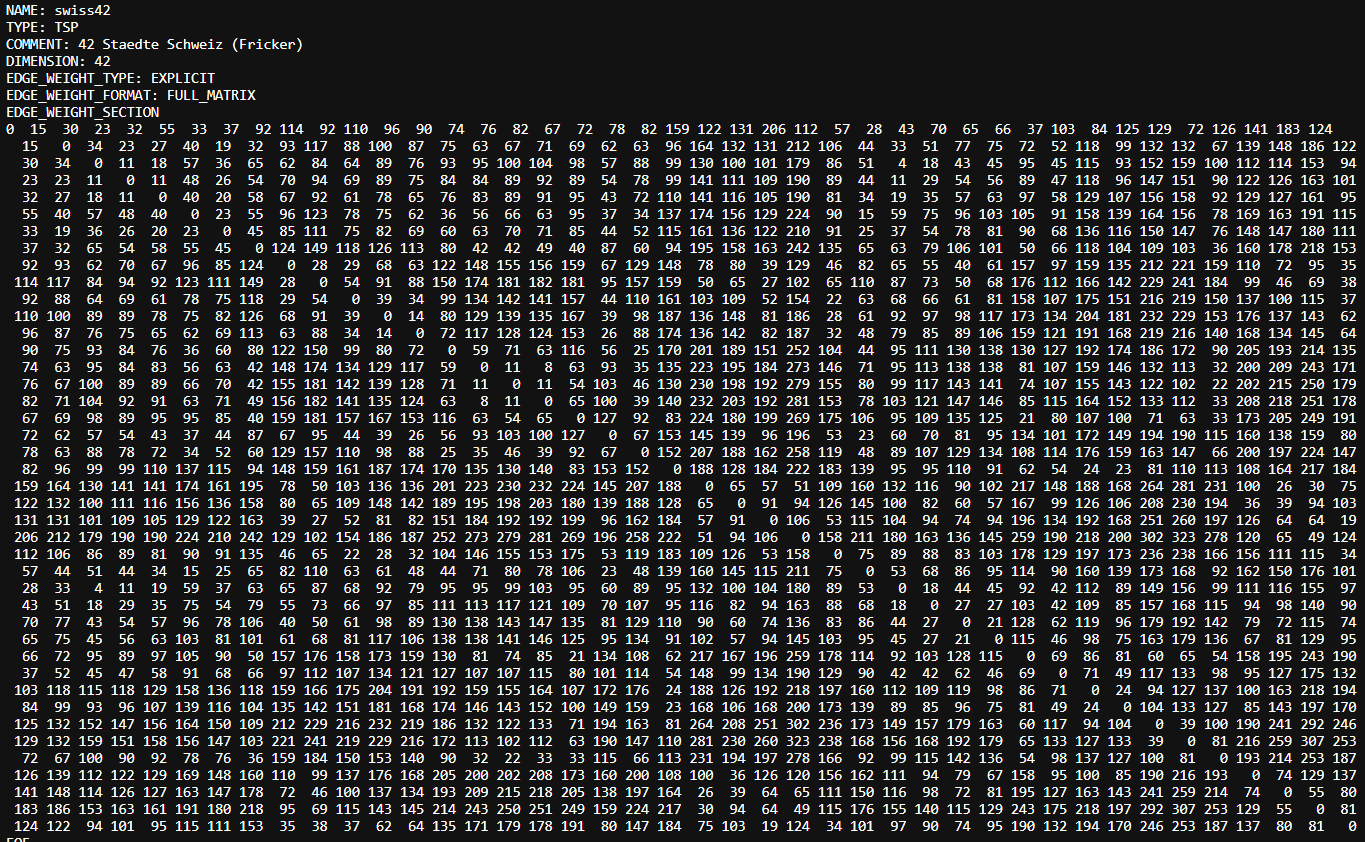

In [4]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [5]:
Nodos

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [6]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [7]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

#Funcionas basicas


In [22]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 29, 22, 18, 40, 19, 38, 14, 12, 25, 31, 6, 41, 7, 3, 15, 39, 17, 36, 26, 2, 13, 21, 27, 34, 32, 16, 24, 11, 23, 5, 8, 9, 33, 30, 37, 28, 35, 4, 10, 1, 20]
5213


#BUSQUEDA ALEATORIA

In [31]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 36, 6, 27, 25, 8, 29, 38, 40, 24, 39, 21, 10, 23, 12, 30, 3, 41, 16, 14, 15, 22, 20, 35, 33, 4, 2, 7, 37, 28, 26, 11, 1, 34, 13, 18, 5, 32, 9, 19, 17, 31]
Distancia     : 3531


#BUSQUEDA LOCAL

In [32]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3531
Distancia Mejor Solucion Local: 3331


In [84]:
###############################################################################
# BUSQUEDA LOCAL (1 paso)
###############################################################################

# Operador SWAP: intercambia dos nodos i y j (manteniendo fijo el nodo 0 si aplica)
# Esta es la operación que realizabamos antes
def vecina_swap(solucion, i, j):
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# Operador 2-OPT: invierte el segmento entre i y j
# (suele ser mejor que swap en problemas tipo TSP porque elimina cruces)
def vecina_2opt(solucion, i, j):
  return solucion[:i] + list(reversed(solucion[i:j+1])) + solucion[j+1:]


# Operador INSERT: saca el nodo en i y lo inserta en la posicion j
def vecina_insert(solucion, i, j):
  vecina = solucion[:]      # copia
  nodo = vecina.pop(i)      # extrae el nodo en i
  vecina.insert(j, nodo)    # lo inserta en j
  return vecina


# Generador de mejor vecina usando VND:
# Probamos varias vecindades. Si una mejora, volvemos a empezar desde la primera.
def genera_vecina(solucion):
  # Lista de operadores de vecindad (puedes reordenarlos si quieres)
  vecindades = ["insert", "swap", "2opt"] # Realizaremos 3 tipos de  operaciones para cada vecina, nos quedaremos con la que mejor resultado tenga

  mejor_solucion = solucion
  mejor_distancia = distancia_total(mejor_solucion, problem)

  k = 0
  while k < len(vecindades):

    # En cada vecindad buscamos la mejor mejora (best-improvement)
    mejor_local = mejor_solucion
    mejor_dist_local = mejor_distancia

    for i in range(1, len(mejor_solucion)-1):     # evitamos el primer nodo
      for j in range(i+1, len(mejor_solucion)):

        # Generamos la vecina segun el operador actual
        if vecindades[k] == "swap":
          vecina = vecina_swap(mejor_solucion, i, j)

        elif vecindades[k] == "2opt":
          vecina = vecina_2opt(mejor_solucion, i, j)

        elif vecindades[k] == "insert":
          vecina = vecina_insert(mejor_solucion, i, j)

        # Evaluamos la vecina
        dist_vecina = distancia_total(vecina, problem)

        # Guardamos si mejora
        if dist_vecina < mejor_dist_local:
          mejor_dist_local = dist_vecina
          mejor_local = vecina

    # Si esta vecindad mejora, aceptamos y volvemos a la primera (intensificacion)
    if mejor_dist_local < mejor_distancia:
      mejor_solucion = mejor_local
      mejor_distancia = mejor_dist_local
      k = 0
    else:
      # Si no mejora, pasamos a la siguiente vecindad (diversificacion)
      k += 1

  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))

nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3531
Distancia Mejor Solucion Local: 1339


In [33]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  32 , la mejor solución encontrada es: [0, 32, 27, 28, 29, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 25, 11, 12, 14, 16, 15, 37, 20, 34, 33, 35, 36, 31, 17, 7, 6, 5, 19, 13, 26, 18, 10, 8, 2, 3, 4, 1]
Distancia     : 1573


#SIMULATED ANNEALING


In [80]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


######################### MEJORA REALIZADA #######################################

# Generador "voraz": en lugar de probar UNA vecina, generamos N vecinas aleatorias
# y nos quedamos con la mejor de todas ellas (búsqueda local por muestreo).
#
# - N_vecinas: número de vecinas que se muestrean en cada iteración.
# - top_k: parámetro para inspeccionar sólo las K mejores del muestreo.
#          Si queremos un comportamiento estrictamente voraz, la mejor del muestreo
#          siempre estará dentro de esas K, así que el resultado es el mismo.
#
# Devuelve: (mejor_vecina, distancia_mejor_vecina) para no recalcular.
def genera_mejor_vecina(solucion, problem, N_vecinas=50):

  candidatas = []  # lista de tuplas: (distancia, solucion_vecina)

  for _ in range(N_vecinas):
    vecina = genera_vecina_aleatorio(solucion)
    dist = distancia_total(vecina, problem)
    candidatas.append((dist, vecina))

  # Ordenamos por distancia (menor = mejor)
  candidatas.sort(key=lambda x: x[0])

  # Nos quedamos con la mejor candidata
  mejor_distancia, mejor_vecina = candidatas[0]  # la mejor del muestreo (voraz)
  # (equivalente a: min(candidatas[:k], key=lambda x: x[0]))

  return mejor_vecina


##################### MEJORA AÑADIDA #########################################
# Funcion de probabilidad para aceptar soluciones peores
def probabilidad(T, d):
  # Si mejora (o empata), aceptar directamente
  if d <= 0:
    return True

  # Evitar divisiones por 0 o temperaturas invalidas
  if T <= 0:
    return False

  return random.random() < math.exp(-d / T) # Si d > 0: se acepta con probabilidad exp(-d/T)


##################### MEJORA AÑADIDA #########################################
#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T * 0.995 if T > 1 else T * 0.95 # Permite diversificar al principio, intensificar al final

In [82]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_mejor_vecina(solucion_referencia, problem, N_vecinas=50)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 26, 18, 12, 11, 25, 10, 8, 9, 41, 23, 40, 24, 21, 39, 22, 38, 30, 29, 28, 3, 1, 7, 17, 31, 36, 35, 20, 33, 34, 32, 27, 2, 4, 6, 5, 13, 19, 14, 16, 15, 37]
con una distancia total de 1407


#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


In [ ]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

In [ ]:
plot_tsp_solution(problem.edge_weights, solucion)